In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [4]:
data = pd.read_csv("../data/student.csv").to_numpy()

# need 1 more col containing 1s so we can have a scaling factor beta_n
expected_output = data[:,-1]
scaling_col = np.ones((data.shape[0], 1))
data = data[:,:-1]
data = np.column_stack((data,scaling_col))


# geneate a parameter matrix 
# size = len(data[0])

rng = np.random.default_rng()
beta_param = rng.normal(0, 0.01, data.shape[1])

print(expected_output)
print(data)
print(data.shape)
print(beta_param)
print(beta_param.shape)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.]
[[0.07 1.  ]
 [0.22 1.  ]
 [0.23 1.  ]
 [0.23 1.  ]
 [0.31 1.  ]
 [0.37 1.  ]
 [0.42 1.  ]
 [0.44 1.  ]
 [0.45 1.  ]
 [0.58 1.  ]
 [0.64 1.  ]
 [0.83 1.  ]
 [0.84 1.  ]
 [0.88 1.  ]
 [0.9  1.  ]
 [0.94 1.  ]
 [0.94 1.  ]
 [0.96 1.  ]
 [1.03 1.  ]
 [1.08 1.  ]
 [1.09 1.  ]
 [1.15 1.  ]
 [1.18 1.  ]
 [1.23 1.  ]
 [1.28 1.  ]
 [1.3  1.  ]
 [1.4  1.  ]
 [1.4  1.  ]
 [1.4  1.  ]
 [1.45 1.  ]


In [15]:
# predicted value 

val = sigmoid(data @ beta_param)
eps = 1e-15
p = np.clip(val, eps, 1 - eps)

# cross-entropy loss 

log_likelihood = np.sum(
    expected_output * np.log(p)
    + (1 - expected_output) * np.log(1 - p)
) / len(data)

print(log_likelihood)

gradient = 1/len(data) * ( data.T @ (p - expected_output) )
learning_rate = 0.5
beta_param -= learning_rate * gradient
epochs =1025

for i in range(0,epochs):

    z = data @ beta_param

    val = sigmoid(z)

    gradient = data.T @ (val - expected_output) / len(expected_output)

    beta_param -= learning_rate * gradient

z = data @ beta_param

p = sigmoid(z)


p = np.clip(p, eps, 1 - eps)

new_log_likelihood = np.mean(
    expected_output * np.log(p)
    + (1 - expected_output) * np.log(1 - p)
)
print(new_log_likelihood)


-0.19177617174659278
-0.19013899756946628


-0.19013282361806383


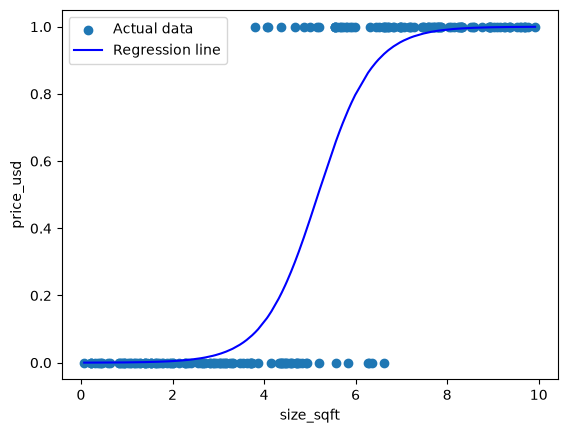

In [16]:

# predicted value 

val = sigmoid(data @ beta_param)
eps = 1e-15
p = np.clip(val, eps, 1 - eps)

# cross-entropy loss 

gradient = 1/len(data) * ( data.T @ (p - expected_output) )
learning_rate = 0.01 
beta_param -= learning_rate * gradient
epochs =1025

for i in range(0,epochs):

    z = data @ beta_param

    val = sigmoid(z)

    gradient = data.T @ (val - expected_output) / len(expected_output)

    beta_param -= learning_rate * gradient

z = data @ beta_param

p = sigmoid(z)


p = np.clip(p, eps, 1 - eps)

new_log_likelihood = np.mean(
    expected_output * np.log(p)
    + (1 - expected_output) * np.log(1 - p)
)
print(new_log_likelihood)


model_prediction = sigmoid(data @ beta_param)

plt.scatter(data[:,0], expected_output, label="Actual data")

plt.plot(data[:,0], model_prediction, color="blue", label="Regression line")

plt.xlabel("size_sqft")
plt.ylabel("price_usd")
plt.legend()
plt.show()

